# Reinforcement Learning Fundamentals

## What is Reinforcement Learning?

Reinforcement Learning (RL) is a type of machine learning where an **agent** learns to make decisions by interacting with an **environment**. Unlike supervised learning (where we have labeled examples) or unsupervised learning (where we find patterns), RL learns through **trial and error** guided by **rewards** and **penalties**.

**Key intuition:** Think of training a dog. You don't tell it exactly what to do you reward good behavior and ignore/correct bad behavior. Over time, the dog learns which actions lead to treats.

### Historical milestones
- **1950s**: Bellman's dynamic programming
- **1989**: Q-Learning (Watkins)
- **1992**: TD-Gammon (Tesauro) backgammon at expert level
- **2013**: DQN Atari from pixels (DeepMind)
- **2016**: AlphaGo defeats world champion
- **2022**: RLHF used in ChatGPT

---

## The Agent-Environment Interface

```
         ┌─────────────────────────────────┐
         │          ENVIRONMENT            │
         │                                 │
         │   State S_t  ──────────────►   │
         │   Reward R_t ──────────────►   │
         │                         AGENT  │
         │          ◄─── Action A_t       │
         └─────────────────────────────────┘
```

At each time step $t$:
1. Agent observes state $S_t$
2. Agent takes action $A_t \sim \pi(\cdot|S_t)$
3. Environment transitions to $S_{t+1}$
4. Agent receives reward $R_{t+1}$

---

## Markov Decision Process (MDP)

Formally, RL problems are modeled as **Markov Decision Processes**:

$$\text{MDP} = (S, A, P, R, \gamma)$$

| Symbol | Name | Description |
|--------|------|-------------|
| $S$ | State space | All possible states |
| $A$ | Action space | All possible actions |
| $P$ | Transition function | $P(s'|s,a)$ prob of next state |
| $R$ | Reward function | $R(s,a,s')$ immediate reward |
| $\gamma$ | Discount factor | $\gamma \in [0,1]$ future reward weight |

### Markov Property

The **Markov property** states that the future depends only on the current state, not the history:

$$P(S_{t+1}|S_t, A_t) = P(S_{t+1}|S_0, A_0, S_1, A_1, ..., S_t, A_t)$$

The present contains all information needed to predict the future.

### Transition Probability

$$P(s'|s,a) = \Pr(S_{t+1}=s' \mid S_t=s, A_t=a)$$

### Discount Factor $\gamma$

- $\gamma = 0$: Only immediate reward matters (myopic)
- $\gamma = 1$: All future rewards equally important
- Typical values: $\gamma \in [0.9, 0.99]$

**Why discount?**
- Mathematical convergence
- Uncertainty of the future
- Preference for sooner rewards

---

## Return

The **return** $G_t$ is the total discounted reward from time $t$:

$$G_t = \sum_{k=0}^{\infty} \gamma^k R_{t+k+1} = R_{t+1} + \gamma R_{t+2} + \gamma^2 R_{t+3} + \cdots$$

**Recursive form** (used in algorithms):

$$G_t = R_{t+1} + \gamma G_{t+1}$$

---

## Policy

A **policy** $\pi$ defines the agent's behavior:

- **Deterministic policy**: $a = \pi(s)$
- **Stochastic policy**: $\pi(a|s) = P(A_t=a \mid S_t=s)$

---

## Value Functions

### State-Value Function

Expected return starting from state $s$ and following policy $\pi$:

$$V^\pi(s) = \mathbb{E}_\pi[G_t \mid S_t=s] = \mathbb{E}_\pi\left[\sum_{k=0}^{\infty}\gamma^k R_{t+k+1} \mid S_t=s\right]$$

### Action-Value Function (Q-function)

Expected return starting from state $s$, taking action $a$, then following $\pi$:

$$Q^\pi(s,a) = \mathbb{E}_\pi[G_t \mid S_t=s, A_t=a]$$

### Relationship

$$V^\pi(s) = \sum_a \pi(a|s) Q^\pi(s,a)$$

$$Q^\pi(s,a) = \sum_{s',r} p(s',r|s,a)\left[r + \gamma V^\pi(s')\right]$$

---

## Bellman Equations

### Bellman Expectation Equation

$$V^\pi(s) = \sum_a \pi(a|s) \sum_{s',r} p(s',r|s,a)\left[r + \gamma V^\pi(s')\right]$$

$$Q^\pi(s,a) = \sum_{s',r} p(s',r|s,a)\left[r + \gamma \sum_{a'} \pi(a'|s') Q^\pi(s',a')\right]$$

### Bellman Optimality Equation

The optimal value functions satisfy:

$$V^*(s) = \max_a \sum_{s',r} p(s',r|s,a)\left[r + \gamma V^*(s')\right]$$

$$Q^*(s,a) = \sum_{s',r} p(s',r|s,a)\left[r + \gamma \max_{a'} Q^*(s',a')\right]$$

**Optimal policy**: $\pi^*(a|s) = \arg\max_a Q^*(s,a)$

---

## Exploration vs Exploitation

The fundamental dilemma:
- **Exploitation**: Use current knowledge to maximize reward
- **Exploration**: Try new actions to discover better strategies

### ε-Greedy

$$\pi(a|s) = \begin{cases} 1-\epsilon + \frac{\epsilon}{|A|} & \text{if } a = \arg\max_{a'} Q(s,a') \\ \frac{\epsilon}{|A|} & \text{otherwise} \end{cases}$$

### Upper Confidence Bound (UCB)

$$A_t = \arg\max_a \left[Q_t(a) + c\sqrt{\frac{\ln t}{N_t(a)}}\right]$$

The second term is an **exploration bonus** actions taken less frequently get a higher bonus.

### Thompson Sampling

Maintain a probability distribution over Q-values. Sample from the distribution, pick the action with highest sampled value. Naturally balances exploration and exploitation via Bayesian reasoning.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# ─── MDP Example: Simple Grid World ───
# States: 0=start, 1=middle, 2=goal, 3=trap
# Actions: 0=left, 1=right

# Transition: P[s][a] = (s', r, done)
transitions = {
    0: {0: (0, -1, False), 1: (1, 0, False)},
    1: {0: (0, 0, False),  1: (2, 10, True)},
    2: {},  # terminal
    3: {},  # terminal
}

print("Simple MDP defined.")
print("States: 0=Start, 1=Middle, 2=Goal(+10), 3=Trap(-10)")
print("Actions: 0=Left, 1=Right")

Simple MDP defined.
States: 0=Start, 1=Middle, 2=Goal(+10), 3=Trap(-10)
Actions: 0=Left, 1=Right


In [2]:
# ─── Return Calculation ───
def compute_return(rewards, gamma=0.99):
    """Compute discounted return G_t from list of rewards."""
    G = 0
    for r in reversed(rewards):
        G = r + gamma * G
    return G

rewards = [0, 0, 0, 10]  # reached goal at step 4
for gamma in [0.5, 0.9, 0.99, 1.0]:
    G = compute_return(rewards, gamma)
    print(f"gamma={gamma:.2f}: G_0 = {G:.4f}")

gamma=0.50: G_0 = 1.2500
gamma=0.90: G_0 = 7.2900
gamma=0.99: G_0 = 9.7030
gamma=1.00: G_0 = 10.0000


In [3]:
# ─── Gymnasium Setup ───
try:
    import gymnasium as gym

    env = gym.make('CartPole-v1')
    obs, info = env.reset(seed=42)

    print(f"Environment: CartPole-v1")
    print(f"Observation space: {env.observation_space}")
    print(f"Action space:      {env.action_space}")
    print(f"Initial obs shape: {obs.shape}")

    # Random policy episode
    total_reward = 0
    obs, info = env.reset()
    for step in range(200):
        action = env.action_space.sample()  # random
        obs, reward, terminated, truncated, info = env.step(action)
        total_reward += reward
        if terminated or truncated:
            break

    print(f"\nRandom policy: survived {step+1} steps, total reward={total_reward}")
    env.close()
except ImportError:
    print("Install: pip install gymnasium")

Environment: CartPole-v1
Observation space: Box([-4.8               -inf -0.41887903        -inf], [4.8               inf 0.41887903        inf], (4,), float32)
Action space:      Discrete(2)
Initial obs shape: (4,)

Random policy: survived 45 steps, total reward=45.0


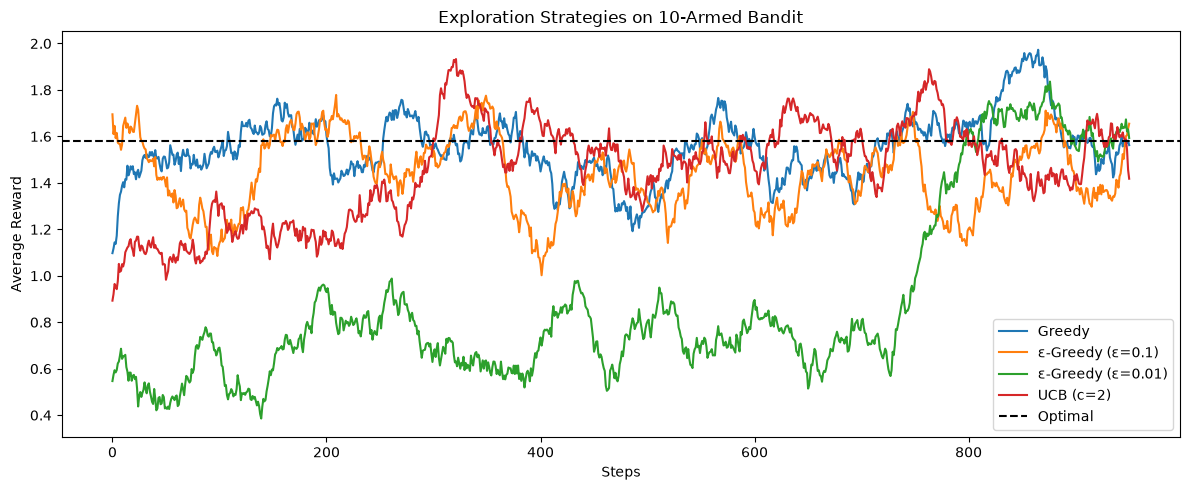

Optimal action value: 1.579


In [4]:
# ─── Exploration Strategies Comparison ───
np.random.seed(42)
n_arms = 10
true_values = np.random.randn(n_arms)  # true Q*(a)
n_steps = 1000

def run_bandit(strategy='epsilon_greedy', epsilon=0.1, c=2.0):
    Q = np.zeros(n_arms)   # estimated values
    N = np.zeros(n_arms)   # action counts
    rewards = []

    for t in range(1, n_steps + 1):
        if strategy == 'epsilon_greedy':
            if np.random.random() < epsilon:
                a = np.random.randint(n_arms)
            else:
                a = np.argmax(Q)

        elif strategy == 'ucb':
            if 0 in N:
                a = np.argmin(N)  # try unvisited first
            else:
                ucb_vals = Q + c * np.sqrt(np.log(t) / N)
                a = np.argmax(ucb_vals)

        elif strategy == 'greedy':
            a = np.argmax(Q)

        # Sample reward from true distribution
        r = true_values[a] + np.random.randn()
        N[a] += 1
        Q[a] += (r - Q[a]) / N[a]  # incremental mean
        rewards.append(r)

    return rewards

strategies = {
    'Greedy': run_bandit('greedy'),
    'ε-Greedy (ε=0.1)': run_bandit('epsilon_greedy', epsilon=0.1),
    'ε-Greedy (ε=0.01)': run_bandit('epsilon_greedy', epsilon=0.01),
    'UCB (c=2)': run_bandit('ucb', c=2.0),
}

plt.figure(figsize=(12, 5))
window = 50
for name, rewards in strategies.items():
    smoothed = np.convolve(rewards, np.ones(window)/window, mode='valid')
    plt.plot(smoothed, label=name)

plt.axhline(y=np.max(true_values), color='black', linestyle='--', label='Optimal')
plt.xlabel('Steps')
plt.ylabel('Average Reward')
plt.title('Exploration Strategies on 10-Armed Bandit')
plt.legend()
plt.tight_layout()
plt.show()
print(f"Optimal action value: {np.max(true_values):.3f}")

## Additional Learning Resources

### Books
- **Reinforcement Learning: An Introduction** Sutton & Barto (free PDF): http://incompleteideas.net/book/the-book-2nd.html
- **Deep Reinforcement Learning Hands-On** Maxim Lapan

### Video Courses
- **David Silver's RL Course** (DeepMind/UCL): https://www.davidsilver.uk/teaching/
- **Spinning Up in Deep RL** OpenAI: https://spinningup.openai.com/
- **Hugging Face Deep RL Course** (free): https://huggingface.co/learn/deep-rl-course

### Papers
- **Playing Atari with DRL** (DQN): https://arxiv.org/abs/1312.5602
- **Human-level control through DRL**: https://www.nature.com/articles/nature14236

### Libraries
- **Gymnasium** (environments): https://gymnasium.farama.org/
- **Stable-Baselines3**: https://stable-baselines3.readthedocs.io/
- **RLlib** (scalable RL): https://docs.ray.io/en/latest/rllib/